# Exploratory Data Analysis (EDA) - FoodVibe

Notebook ini digunakan untuk melihat dan mengeksplorasi dataset `food_coded.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/food_coded.csv')
df.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


In [3]:
# Info Dataset
print("Shape dataset:", df.shape)
df.info()

Shape dataset: (125, 61)
<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    str    
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    str    
 8   comfort_food_reasons          123 non-null    str    
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    floa

In [4]:
# Cek missing values (Nilai Kosong)
missing_data = df.isnull().sum()
missing_data[missing_data > 0].sort_values(ascending=False)

type_sports                   26
calories_day                  19
comfort_food_reasons_coded    19
cuisine                       17
exercise                      13
employment                     9
mother_education               3
father_profession              3
cook                           3
eating_changes                 3
meals_dinner_friend            3
GPA                            2
fav_food                       2
sports                         2
mother_profession              2
fav_cuisine                    2
drink                          2
comfort_food_reasons           2
weight                         2
food_childhood                 1
calories_scone                 1
diet_current                   1
comfort_food                   1
father_education               1
life_rewarding                 1
healthy_meal                   1
marital_status                 1
ideal_diet                     1
income                         1
on_off_campus                  1
soup      

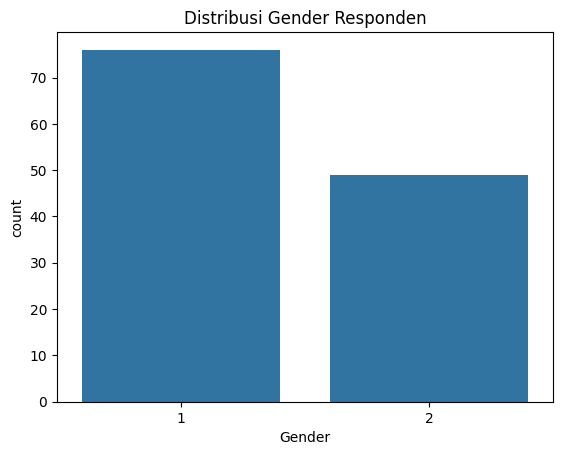

In [5]:
# Melihat distribusi gender atau variabel lain (contoh)
# Asumsi kolom 'Gender' bernilai numerik, kita plot
sns.countplot(x='Gender', data=df)
plt.title('Distribusi Gender Responden')
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATASET
df = pd.read_csv('../data/raw/food_coded.csv')

# 2. FEATURE SELECTION
selected_features = [
    'comfort_food_reasons_coded', # Mewakili Mood
    'eating_out',                 # Mewakili Waktu/Lifestyle
    'fries',                      # Mewakili Rasa
    'nutritional_check',          # Mewakili Lifestyle
    'diet_current_coded'          # Target Kelasnya
]
df_selected = df[selected_features].copy()

# 3. DATA CLEANING (Imputasi Modus)
for col in df_selected.columns:
    if df_selected[col].isnull().sum() > 0:
        mode_value = df_selected[col].mode()[0]
        df_selected[col] = df_selected[col].fillna(mode_value)

# 4. TARGET MAPPING (Binarisasi Target)
# Mengubah target menjadi 1 (Healthy) dan 0 (Unhealthy)
df_selected['target'] = df_selected['diet_current_coded'].apply(lambda x: 1 if x == 1 else 0)

# 5. TRAIN-TEST SPLIT
X = df_selected.drop(columns=['diet_current_coded', 'target'])
y = df_selected['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("=== DATA SIAP UNTUK MODELING ===")
print(f"Jumlah Data Latih (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (X_test): {X_test.shape[0]} baris")
print("\nDistribusi Target Baru:")
print(df_selected['target'].value_counts())

=== DATA SIAP UNTUK MODELING ===
Jumlah Data Latih (X_train): 100 baris
Jumlah Data Uji (X_test): 25 baris

Distribusi Target Baru:
target
0    75
1    50
Name: count, dtype: int64


=== HASIL EVALUASI MODEL ===

--- Logistic Regression (Baseline) ---
Accuracy: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.67      0.74        15
           1       0.62      0.80      0.70        10

    accuracy                           0.72        25
   macro avg       0.72      0.73      0.72        25
weighted avg       0.75      0.72      0.72        25



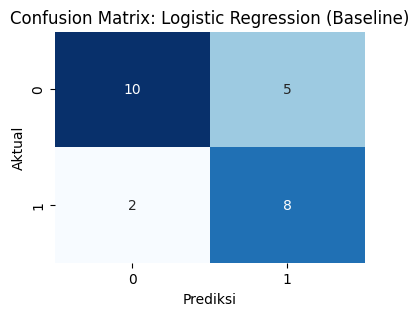

--- Random Forest (Utama) ---
Accuracy: 0.40
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40        15
           1       0.33      0.50      0.40        10

    accuracy                           0.40        25
   macro avg       0.42      0.42      0.40        25
weighted avg       0.43      0.40      0.40        25



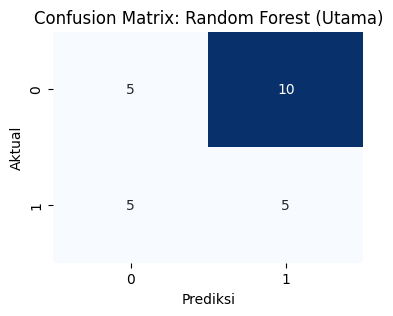

--- SVM (Eksplorasi) ---
Accuracy: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.47      0.61        15
           1       0.53      0.90      0.67        10

    accuracy                           0.64        25
   macro avg       0.70      0.68      0.64        25
weighted avg       0.74      0.64      0.63        25



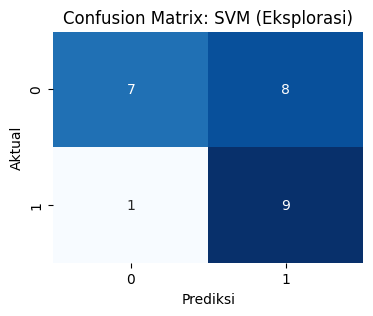


[INFO] Model Random Forest telah disimpan sebagai 'best_model.pkl' di folder models/


In [4]:
# ==========================================
# FASE 2: MODEL TRAINING & EVALUATION
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib # Untuk menyimpan model

# 1. Inisialisasi Model dengan parameter class_weight='balanced' sesuai proposal
models = {
    "Logistic Regression (Baseline)": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest (Utama)": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM (Eksplorasi)": SVC(class_weight='balanced', kernel='rbf', probability=True, random_state=42)
}

# 2. Dictionary untuk menyimpan hasil visualisasi PPT nanti
best_f1_score = 0
best_model_name = ""

# 3. Looping untuk melatih dan mengevaluasi setiap model
print("=== HASIL EVALUASI MODEL ===\n")
for name, model in models.items():
    # Training Model
    model.fit(X_train, y_train)
    
    # Prediksi Data Uji (Testing)
    y_pred = model.predict(X_test)
    
    # Evaluasi Metrik
    acc = accuracy_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Visualisasi Confusion Matrix (Bagus untuk ditaruh di PPT)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

# 4. Menyimpan Model Random Forest (Asumsi model utama) untuk Deployment
# Nanti kita bisa ubah jika ternyata SVM atau Logistic Regression hasilnya lebih bagus
rf_model = models["Random Forest (Utama)"]
joblib.dump(rf_model, '../models/best_model.pkl')
print("\n[INFO] Model Random Forest telah disimpan sebagai 'best_model.pkl' di folder models/")